# Exploring Chemical Space
On the modified ESOL dataset, some clustering techniques to explore the physicochemical diversity should be explored. Include dimensionality reduction before and visualise!

Import data

In [1]:
import pandas as pd
import numpy as np

# Load your modified ESOL dataset
df = pd.read_csv("esol_modified.csv")

# Remove non-numeric columns (keep descriptors only)
X = df.select_dtypes(include=[np.number]).copy()

# Optional: drop target column if present (e.g., logS)
if "logS" in X.columns:
    X = X.drop(columns=["logS"])

print("Shape after numeric selection:", X.shape)

Shape after numeric selection: (1128, 12)


In [5]:
df.duplicated().sum()

np.int64(0)

Remove low-variance features

In [6]:
from sklearn.feature_selection import VarianceThreshold

var_filter = VarianceThreshold(threshold=0.01)
X_var = var_filter.fit_transform(X)

X = pd.DataFrame(X_var, columns=X.columns[var_filter.get_support()])
print("After variance filter:", X.shape)

After variance filter: (1128, 12)


Remove Highly Correlated Features (>0.9)

In [7]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X = X.drop(columns=to_drop)

print("After correlation filtering:", X.shape)

After correlation filtering: (1128, 10)


Scale the data

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

PCA (for clustering space)

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X_scaled.shape[1])
print("PCA dimensions:", X_pca.shape[1])

Original dimensions: 10
PCA dimensions: 3


Visualisation: t-SNE

In [11]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

Visualisation: UMAP

In [12]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

c:\Users\jschoer\Desktop\DSA104development\DSA104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


KMeans Clustering on PCA Space

In [14]:
# Find optimal k using silhouette score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

range_k = range(2, 9)
sil_scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    sil_scores.append(silhouette_score(X_pca, labels))

best_k = range_k[np.argmax(sil_scores)]
print("Best k:", best_k)

Best k: 4


In [16]:
# fit final KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(X_pca)

df["KMeans_cluster"] = kmeans_labels

DBSCAN Clustering on PCA space

In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=5)
db_labels = dbscan.fit_predict(X_pca)

df["DBSCAN_cluster"] = db_labels

print("Number of DBSCAN clusters:",
      len(set(db_labels)) - (1 if -1 in db_labels else 0))
print("Noise points:", list(db_labels).count(-1))

Number of DBSCAN clusters: 3
Noise points: 115


Evaluation metrics

In [18]:
from sklearn.metrics import davies_bouldin_score

print("KMeans silhouette:",
      silhouette_score(X_pca, kmeans_labels))

print("KMeans davies_bouldin_score:",
      davies_bouldin_score(X_pca, kmeans_labels))

if len(set(db_labels)) > 1:
    print("DBSCAN silhouette:",
          silhouette_score(X_pca, db_labels))

if len(set(db_labels)) > 1:
    print("DBSCAN davies_bouldin_score:",
          davies_bouldin_score(X_pca, db_labels))

KMeans silhouette: 0.36088793142213815
KMeans davies_bouldin_score: 1.0135285104200282
DBSCAN silhouette: 0.05842855458658477
DBSCAN davies_bouldin_score: 1.6653435163158141


Visualisation of clusters - project KMeans clustering on PCA, tSNE, UMAP

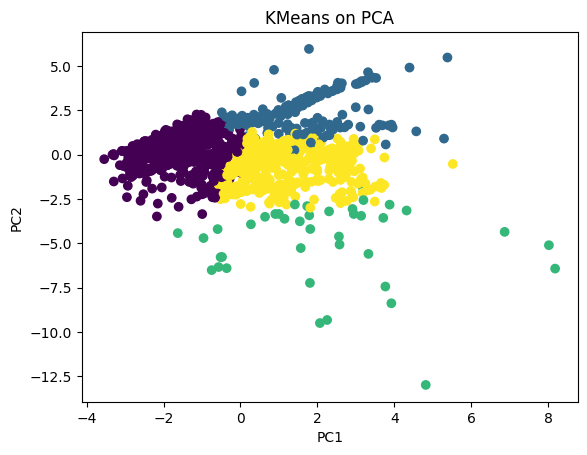

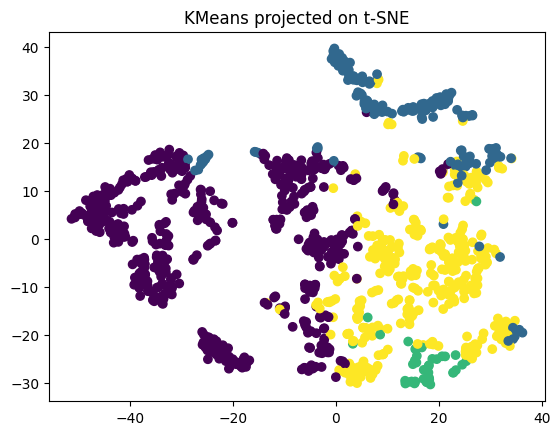

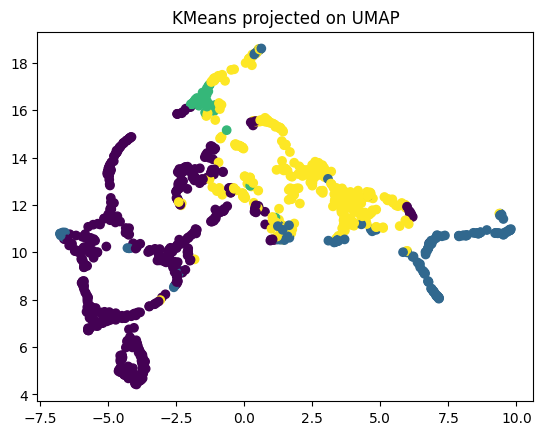

In [19]:
import matplotlib.pyplot as plt

# PCA 2D plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("KMeans on PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# t-SNE plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels)
plt.title("KMeans projected on t-SNE")
plt.show()


# UMAP plot
plt.figure()
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=kmeans_labels)
plt.title("KMeans projected on UMAP")
plt.show()

Visualisation of clusters - project DBSCAN clustering on PCA, tSNE, UMAP

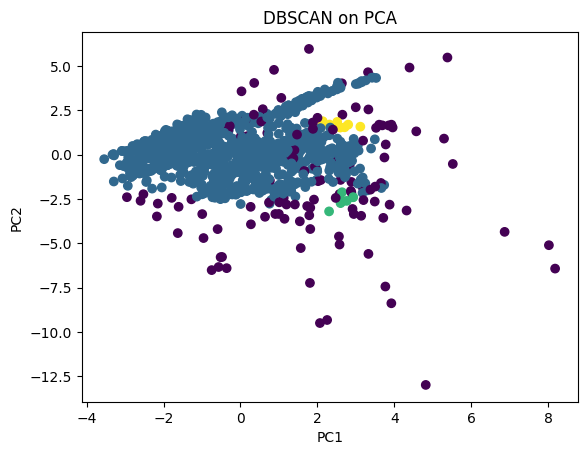

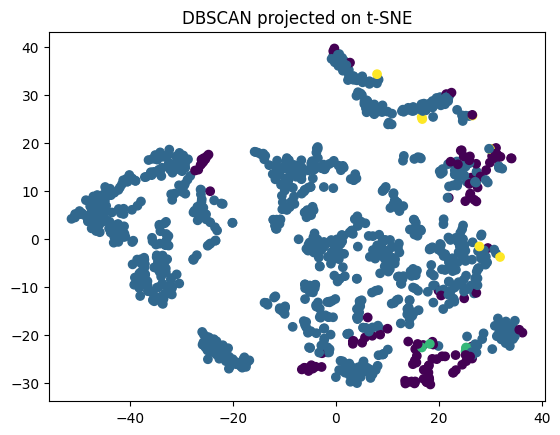

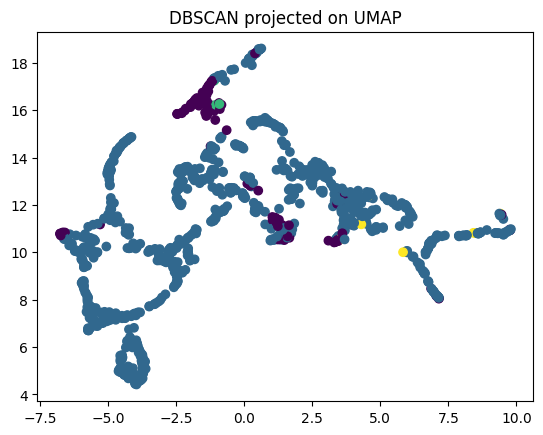

In [20]:
# PCA 2D plot
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels)
plt.title("DBSCAN on PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# t-SNE plot
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=db_labels)
plt.title("DBSCAN projected on t-SNE")
plt.show()


# UMAP plot
plt.figure()
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=db_labels)
plt.title("DBSCAN projected on UMAP")
plt.show()

Access Molecules from clusters via cluster labels:

In [21]:
df["KMeans_cluster"] = kmeans_labels
df["DBSCAN_cluster"] = db_labels

In [22]:
df

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount,KMeans_cluster,DBSCAN_cluster
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.770,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0,2,-1
1,Cc1occc1C(=O)Nc2ccccc2,-3.300,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0,3,0
2,CC(C)=CCCC(C)=CC(=O),-2.060,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0,0,0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.870,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0,1,0
4,c1ccsc1,-1.330,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,FC(F)(F)C(Cl)Br,-1.710,197.381,2.50850,0.000000,0.00,0.0,0.0,7.0,0.0,0.523506,0.0,0.0,0,0
1124,CNC(=O)ON=C(SC)C(=O)N(C)C,0.106,219.266,0.10710,11.947582,71.00,5.0,0.0,14.0,0.0,0.293876,1.0,6.0,0,0
1125,CCSCCSP(=S)(OC)OC,-3.091,246.359,2.99000,0.000000,18.46,5.0,0.0,12.0,0.0,0.506070,0.0,2.0,0,0
1126,CCC(C)C,-3.180,72.151,2.05240,6.420822,0.00,0.0,0.0,5.0,0.0,0.444441,0.0,0.0,0,0


In [24]:
# Get all molecules from KMeans cluster 0
cluster_0 = df[df["KMeans_cluster"] == 1]

print(cluster_0[["SMILES"]].head())
print("Cluster size:", len(cluster_0))

                                            SMILES
3               c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
6               Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl
8   ClC4=C(Cl)C5(Cl)C3C1CC(C2OC12)C3C4(Cl)C5(Cl)Cl
11                                Clc1ccc2ccccc2c1
14                                  CCCCCCCCCCCCCC
Cluster size: 177


In [25]:
# Get the DBSCAN Noise Molecules (outliers = intersting molecules?)
noise = df[df["DBSCAN_cluster"] == -1]

print("Number of outliers:", len(noise))
print(noise[["SMILES"]].head())

Number of outliers: 115
                                               SMILES
0   OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
9    COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C 
14                                     CCCCCCCCCCCCCC
24       CCN(CC)c1c(cc(c(N)c1N(=O)=O)C(F)(F)F)N(=O)=O
48   COC(=O)C1=C(C)NC(=C(C1c2ccccc2N(=O)=O)C(=O)OC)C 


Identify representative molecules for KMeans clusters via centroids:

In [26]:
from scipy.spatial.distance import cdist

cluster_id = 2

cluster_indices = np.where(kmeans_labels == cluster_id)[0]
cluster_points = X_pca[cluster_indices]

centroid = kmeans.cluster_centers_[cluster_id].reshape(1, -1)

distances = cdist(cluster_points, centroid)
closest_index = cluster_indices[np.argmin(distances)]

representative_molecule = df.iloc[closest_index]

print("Representative SMILES:", representative_molecule["SMILES"])

Representative SMILES: OCC1OC(C(O)C1O)n2cnc3c(O)ncnc23


Visualise Molecules from certain clusters via RDKIT

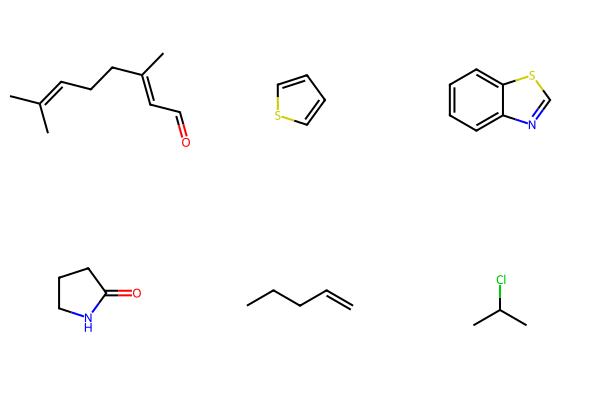

In [27]:
from rdkit import Chem
from rdkit.Chem import Draw

cluster_0 = df[df["KMeans_cluster"] == 0].head(6)

mols = [Chem.MolFromSmiles(sm) for sm in cluster_0["SMILES"]]

Draw.MolsToGridImage(mols, molsPerRow=3)

Compare clusters accross methods (where is the noise located? are clusters consistent?)

In [28]:
pd.crosstab(df["KMeans_cluster"], df["DBSCAN_cluster"])

DBSCAN_cluster,-1,0,1,2
KMeans_cluster,,,,
0,10,530,0,0
1,36,133,0,8
2,39,0,1,0
3,30,335,6,0


Cluster Exploration: Compare for each cluster

1) Report cluster size
2) Report centroid representative molecule
3) Show 4–6 example structures
4) Report key descriptor means
5) Compare to global dataset mean

In [31]:
summary = df.groupby("KMeans_cluster").agg({
    "LogS": "mean",
    "MolWt": "mean",
    "LogP": "mean",
    "NumHDonors": "mean",
    "NumHAcc": "mean"
})

print(summary)

                    LogS       MolWt      LogP  NumHDonors   NumHAcc
KMeans_cluster                                                      
0              -1.847272  126.862641  1.853087    0.387037  1.040741
1              -6.242418  286.277136  5.203749    0.101695  0.988701
2              -1.838825  325.694300 -1.211565    4.350000  7.625000
3              -3.408429  263.709889  2.392275    1.051213  3.611860


In [ ]:
summary2 = df.groupby("KMeans_cluster")["LogS"].mean()
print(summary2)